## 1. Problem Definition

Natural Language Processing (NLP) revolutionizes the media industry by automating news categorization, allowing organizations to efficiently manage the tremendous volume of news articles generated daily. By leveraging NLP, media outlets can quickly and accurately classify articles into relevant topics such as Politics, Sports, Technology, Entertainment, and Health. This automation not only saves valuable human effort and reduces errors but also ensures a consistent user experience by organizing and presenting content in a more structured and accessible manner.

## 2. Data Collection & Loading

In [1]:
# import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
from tqdm import tqdm
tqdm.pandas()
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
# Load the dataset
df = pd.read_csv('train.csv')

# Display the shape
print('Dataset shape: ', df.shape)

# Display the first 10 rows
print('\nThe first 10 rows: \n')
df.head(10)

Dataset shape:  (120000, 3)

The first 10 rows: 



,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


## 3. Exploratory Data Analysis (EDA)

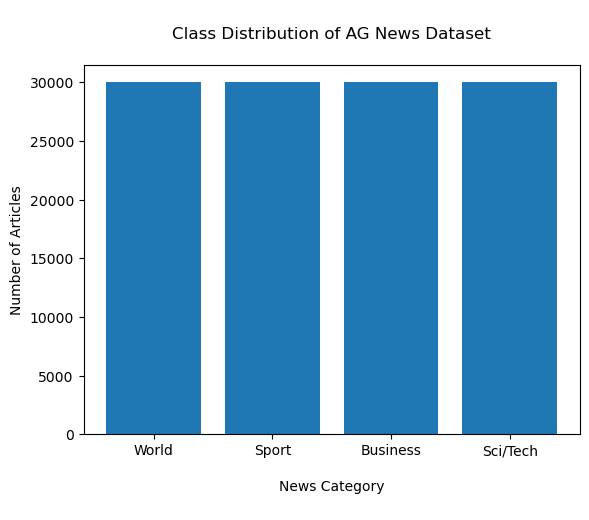

,Class Index,Title,Description
71787,3,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,..."
67218,3,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...
54066,2,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...


In [3]:
# import matplotlib.pyplot as plt (imported above) 

# Check for class distribution
class_counts = df['Class Index'].value_counts().sort_index()
class_names = ['World','Sport', 'Business', 'Sci/Tech']
plt.bar(class_names, class_counts.values)
plt.xlabel('\nNews Category\n')
plt.ylabel('Number of Articles')
plt.title('\nClass Distribution of AG News Dataset\n')
plt.show()

df.sample(3, random_state=42)[['Class Index', 'Title', 'Description']]

## 4. Text Preprocessing

In [4]:
# import spacy
# from tqdm import tqdm
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
def preprocess(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    return ' '.join(tokens)

#preprocess a small sample
for text in df['Description'].sample(5, random_state=42):
    print(f'Original: {text}\nProcessed: {preprocess(text)}\n' )



Original: London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.
Processed: london british broadcasting corporation world big public broadcaster cut quarter strong workforce big shake year history time newspaper london say monday

Original: Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos.
Processed: embattle insurance broker bank agree waive clause prevent access credit new york reuters marsh amp mclennan cos

Original: AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 10-year career.
Processed: ap derek jeter turn season start terrible slump good accomplished year career

Original: When the Genesis capsule comes back to Earth with its samples

In [5]:
# Preprocess all descriptions
df['Processed']=df['Description'].progress_apply(preprocess)
df[['Processed', 'Description']].head(10)

100%|██████████| 120000/120000 [30:06<00:00, 66.43it/s] 


,Processed,Description
0,reuters short seller wall street ultra cynic s...,"Reuters - Short-sellers, Wall Street's dwindli..."
1,reuters private investment firm carlyle reputa...,Reuters - Private investment firm Carlyle Grou...
2,reuters soar crude price plus economy outlook ...,Reuters - Soaring crude prices plus worries\ab...
3,reuters authority halt oil main pipeline south...,Reuters - Authorities have halted oil export\f...
4,afp tearaway world oil price topple record str...,"AFP - Tearaway world oil prices, toppling reco..."
5,reuters stock end slightly high stay near low ...,Reuters - Stocks ended slightly higher on Frid...
6,ap asset nation retail money market mutual fun...,AP - Assets of the nation's retail money marke...
7,retail sale bounce bit july new claim jobless ...,USATODAY.com - Retail sales bounced back a bit...
8,earn sociology danny bazil riley start work ge...,Forbes.com - After earning a PH.D. in Sociolog...
9,new york reuters short seller wall street dwin...,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


## 5. Feature Engineering

We'll convert text to numerical features using TF-IDF.

In [6]:
# from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['Processed'])
print('TF-IDF matrix shape:', X.shape)

TF-IDF matrix shape: (120000, 5000)


## 6. Model Training & Evaluation

We'll train a Logistic Regression model.

In [10]:
# from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import classification_report, confusion_matrix
#from sklearn.model_selection import train_test_split

# Prepare labels (AG News Articles)
y = df['Class Index']-1

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state =42)

# Train a model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       World       0.91      0.89      0.90      5956
       Sport       0.94      0.97      0.95      6058
    Business       0.86      0.87      0.86      5911
    Sci/Tech       0.88      0.86      0.87      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000

